In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np

df = pd.read_parquet('/content/drive/MyDrive/cyber_projekat/data/DoS-Wednesday-no-metadata.parquet')
print(df.shape)
print(df.head())

(584991, 78)
   Protocol  Flow Duration  Total Fwd Packets  Total Backward Packets  \
0         6          38308                  1                       1   
1         6            479                 11                       5   
2         6           1095                 10                       6   
3         6          15206                 17                      12   
4         6           1092                  9                       6   

   Fwd Packets Length Total  Bwd Packets Length Total  Fwd Packet Length Max  \
0                         6                         6                      6   
1                       172                       326                     79   
2                      3150                      3150                   1575   
3                      3452                      6660                   1313   
4                      3150                      3152                   1575   

   Fwd Packet Length Min  Fwd Packet Length Mean  Fwd Packet Length

In [ ]:
print(df.columns.tolist())

['Protocol', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Fwd Packets Length Total', 'Bwd Packets Length Total', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Packet Length Min', 'Packet Length Max', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag Count', 'ECE Flag Count', 'Down/Up Ra

In [ ]:
print(df.dtypes)
print(df.isnull().sum())

Protocol                        int8
Flow Duration                  int32
Total Fwd Packets              int32
Total Backward Packets         int32
Fwd Packets Length Total       int32
                              ...   
Idle Mean                    float32
Idle Std                     float32
Idle Max                       int32
Idle Min                       int32
Label                       category
Length: 78, dtype: object
Protocol                    0
Flow Duration               0
Total Fwd Packets           0
Total Backward Packets      0
Fwd Packets Length Total    0
                           ..
Idle Mean                   0
Idle Std                    0
Idle Max                    0
Idle Min                    0
Label                       0
Length: 78, dtype: int64


In [ ]:
print(df['Label'].value_counts())

Label
Benign              391235
DoS Hulk            172846
DoS GoldenEye        10286
DoS slowloris         5385
DoS Slowhttptest      5228
Heartbleed              11
Name: count, dtype: int64


In [ ]:
df['Label'] = df['Label'].apply(lambda x: 0 if x == 'Benign' else 1)
print(df['Label'].value_counts())

Label
0    391235
1    193756
Name: count, dtype: int64


In [ ]:
X = df.drop(columns=['Label'])
y = df['Label']
print(X.shape)
print(y.value_counts())

(584991, 77)
Label
0    391235
1    193756
Name: count, dtype: int64


In [ ]:
df_features = X.copy()
asimetrija = pd.DataFrame(df_features).skew()
print("Kolone sa visokim skewnessem (>1):")
visoka_asimetrija = asimetrija[abs(asimetrija) > 1]
print(f"Broj kolona sa skewness > 1: {len(visoka_asimetrija)}")
print(visoka_asimetrija.sort_values(ascending=False).head(20))

Kolone sa visokim skewnessem (>1):
Broj kolona sa skewness > 1: 58
Total Backward Packets      225.705601
Subflow Bwd Packets         225.705601
Bwd Header Length           225.514780
Fwd Header Length           224.906401
Subflow Fwd Packets         224.443832
Total Fwd Packets           224.443832
Fwd Act Data Packets        224.402456
Subflow Bwd Bytes           223.712311
Bwd Packets Length Total    223.701880
Flow Bytes/s                152.716969
Fwd Packets Length Total    110.869415
Subflow Fwd Bytes           110.869415
RST Flag Count               49.969738
ECE Flag Count               49.863178
Active Std                   35.923882
Bwd Packets/s                33.247150
Fwd Packet Length Min        24.040976
Active Min                   22.119188
Flow IAT Min                 20.680258
Active Max                   19.379016
dtype: float64


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler,StandardScaler
#58 od 77 kolona pokazuje visoku asimetriju tako da je bolji izbor RobustScaler od StandardScalera
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
#normalizacija
scaler = StandardScaler()
#scaler = RobustScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(X_train.shape)
print(X_test.shape)

(467992, 77)
(116999, 77)


In [ ]:
#resavanje neravnoteze
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_sm,y_train_sm = smote.fit_resample(X_train,y_train)
print(y_train_sm.value_counts())

Label
0    313029
1    313029
Name: count, dtype: int64


In [ ]:
import tensorflow as tf
from tensorflow import keras

model = keras.Sequential([
    keras.layers.Dense(128, activation='relu', input_shape=(X_train_sm.shape[1],)),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 128)            │         9,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,353 (79.50 KB)

 Trainable params: 20,353 (79.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train_sm, y_train_sm,
    epochs=10,
    batch_size=512,
    validation_split=0.2,
    verbose=1
)

Epoch 1/10
979/979 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.9713 - loss: 0.0687 - val_accuracy: 0.9854 - val_loss: 0.0424
Epoch 2/10
979/979 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.9834 - loss: 0.0366 - val_accuracy: 0.9568 - val_loss: 0.0551
Epoch 3/10
979/979 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.9860 - loss: 0.0313 - val_accuracy: 0.9952 - val_loss: 0.0262
Epoch 4/10
979/979 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.9874 - loss: 0.0288 - val_accuracy: 0.9879 - val_loss: 0.0355
Epoch 5/10
979/979 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.9875 - loss: 0.0282 - val_accuracy: 0.9909 - val_loss: 0.0290
Epoch 6/10
979/979 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9879 - loss: 0.0274 - val_accuracy: 0.9804 - val_loss: 0.0394
Epoch 7/10
979/979 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.9885 - loss: 0.0270 - val_accuracy: 0.9957 - val_loss: 0.0182
Epoch 8/10
979/979 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9896 - loss: 0.0250 - val_accuracy:

3657/3657 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step
              precision    recall  f1-score   support

      Benign       1.00      0.98      0.99     78206
       Napad       0.97      1.00      0.98     38793

    accuracy                           0.99    116999
   macro avg       0.98      0.99      0.99    116999
weighted avg       0.99      0.99      0.99    116999



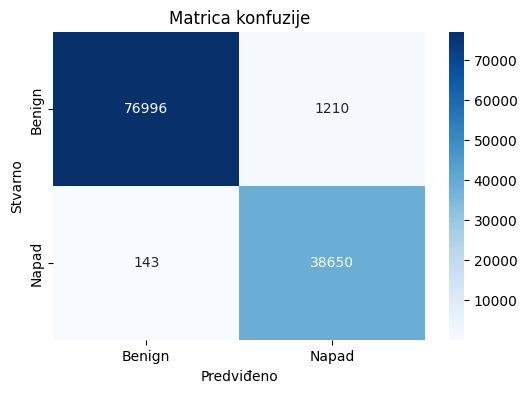

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Predikcije
y_pred = (model.predict(X_test) > 0.5).astype(int)

# Classification report
print(classification_report(y_test, y_pred, target_names=['Benign', 'Napad']))


cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Napad'],
            yticklabels=['Benign', 'Napad'])
plt.title('Matrica konfuzije')
plt.ylabel('Stvarno')
plt.xlabel('Predviđeno')
plt.show()

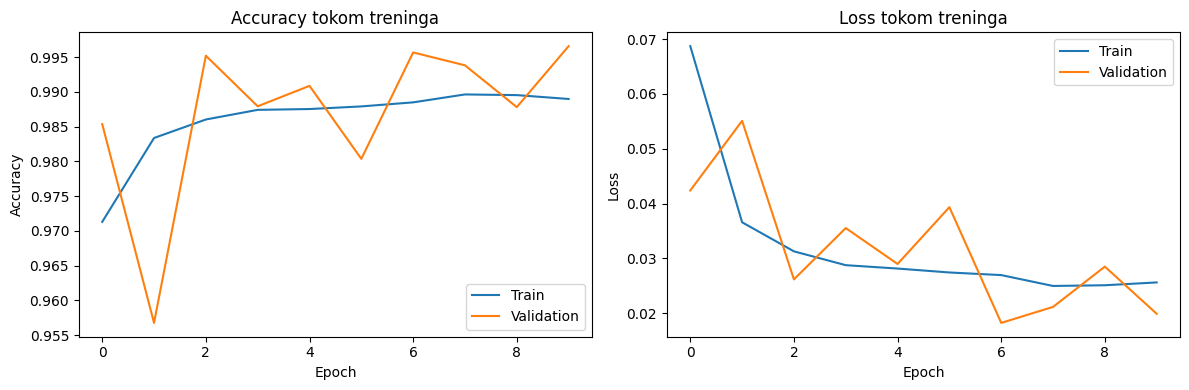

In [ ]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Accuracy tokom treninga')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Loss tokom treninga')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()